# Results Overview — `career_position` Annotation

Aggregates all submitted results from `results/register.csv` for the `annotation / career_position` task.
Models are grouped by architecture family and shown for both **broad** (9 sectors) and **fine-grained** (~100 codes) granularities.

> Run all cells to regenerate after new results are submitted.

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Find the project root (directory that contains results/register.csv)
# Works regardless of working directory or how the notebook is launched
def _find_register():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "results" / "register.csv"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Cannot locate results/register.csv — run from within the corex_eval project")

REGISTER = _find_register()
print(f"Register: {REGISTER}")

TASK = "annotation"
VAR  = "career_position"

Register: /tmp/pycharm_project_967/results/register.csv


## 1. Model catalogue
All planned experiments, grouped by family, for both granularities.

In [11]:
# ── Full experiment catalogue ─────────────────────────────────────────────────
# Each entry: (family, display_name, experiment_folder_broad, experiment_folder_fine)
CATALOGUE = [
    # --- Encoders (fine-tuned) ---
    ("Encoder", "mBERT",          "bert_finetuned_career_broad",         "bert_finetuned_career"),
    ("Encoder", "BERT-EN",        "bert_english_finetuned_career_broad", "bert_english_finetuned_career"),
    ("Encoder", "XLM-RoBERTa",   "xlmroberta_finetuned_career_broad",   "xlmroberta_finetuned_career"),
    # --- Open-source LLMs (LM Studio) ---
    ("OSS LLM", "GPT-OSS 20B",   "lmstudio_gptoss20b_broad",            "lmstudio_gptoss20b_fine"),
    ("OSS LLM", "Llama 3.3 70B", "lmstudio_llama33_70b_broad",          "lmstudio_llama33_70b_fine"),
    ("OSS LLM", "Qwen3 80B",     "lmstudio_qwen3_80b_broad",            "lmstudio_qwen3_80b_fine"),
    # --- Closed-source LLMs ---
    ("Closed",  "GPT-4o",        "gpt4o_broad",                         "gpt4o_fine"),
    ("Closed",  "GPT-5.3",       "gpt53_broad",                         "gpt53_fine"),
    ("Closed",  "Claude Opus 4.6","claude_opus46_broad",                 "claude_opus46_fine"),
    ("Closed",  "Gemini 2.5 Flash","gemini25flash_broad",                "gemini25flash_fine"),
    # --- RAG ---
    ("RAG",     "RAG-Embeddings","rag_embeddings_broad",                 "rag_embeddings_fine"),
    ("RAG",     "RAG-WebSearch", "rag_websearch_broad",                  "rag_websearch_fine"),
]

FAMILY_ORDER  = ["Encoder", "OSS LLM", "Closed", "RAG"]
FAMILY_COLORS = {
    "Encoder": "#4C72B0",
    "OSS LLM": "#55A868",
    "Closed":  "#C44E52",
    "RAG":     "#DD8452",
}

print(f"{len(CATALOGUE)} experiments planned")

12 experiments planned


## 2. Load register & match to catalogue

In [12]:
reg = pd.read_csv(REGISTER)
reg = reg[(reg["task"] == TASK) & (reg["variable"] == VAR)].copy()

# Extract the experiment folder name from the path (last directory component before /config.yaml)
def _exp_folder(path):
    p = str(path)
    parts = p.replace("\\", "/").split("/")
    # e.g. …/experiments/annotation/bert_finetuned_career_broad/config.yaml
    if len(parts) >= 2:
        return parts[-2]
    return p

reg["exp_folder"] = reg["experiment_path"].apply(_exp_folder)

# Cast metric columns to numeric
for col in ["accuracy", "macro_f1", "weighted_f1", "precision", "recall", "f1"]:
    reg[col] = pd.to_numeric(reg[col], errors="coerce")

# For each experiment folder keep only the best accuracy row
# (handles reruns; zero-accuracy rows from before workplace fix are superseded)
reg_best = (
    reg[reg["accuracy"] > 0]          # drop clearly broken runs
    .sort_values("accuracy", ascending=False)
    .drop_duplicates(subset="exp_folder", keep="first")
    .set_index("exp_folder")
)

print(f"Register rows after filtering: {len(reg_best)}")
print("Matched folders:", list(reg_best.index))

Register rows after filtering: 7
Matched folders: ['bert_english_finetuned_career_broad', 'xlmroberta_finetuned_career_broad', 'bert_finetuned_career_broad', 'config.yaml', 'bert_finetuned_career', 'bert_english_finetuned_career', 'xlmroberta_finetuned_career']


In [4]:
def build_results_df(granularity):
    """Build a summary DataFrame for 'broad' or 'fine' granularity."""
    folder_col = 2 if granularity == "broad" else 3
    records = []
    for family, name, broad_folder, fine_folder in CATALOGUE:
        folder = broad_folder if granularity == "broad" else fine_folder
        if folder in reg_best.index:
            row = reg_best.loc[folder]
            records.append({
                "Family":      family,
                "Model":       name,
                "Accuracy":    round(row["accuracy"], 4),
                "Macro F1":    round(row["macro_f1"], 4) if pd.notna(row["macro_f1"]) else None,
                "Weighted F1": round(row["weighted_f1"], 4) if pd.notna(row["weighted_f1"]) else None,
            })
        else:
            records.append({
                "Family":      family,
                "Model":       name,
                "Accuracy":    None,
                "Macro F1":    None,
                "Weighted F1": None,
            })

    df = pd.DataFrame(records)
    df["Family"] = pd.Categorical(df["Family"], categories=FAMILY_ORDER, ordered=True)
    return df.sort_values(["Family", "Model"]).reset_index(drop=True)

df_broad = build_results_df("broad")
df_fine  = build_results_df("fine")

---
## 3. Broad sector results (9 classes)

In [5]:
def style_table(df):
    """Return a styled DataFrame with TBD for missing values."""
    display_df = df.copy()
    for col in ["Accuracy", "Macro F1", "Weighted F1"]:
        display_df[col] = display_df[col].apply(
            lambda x: f"{x:.4f}" if pd.notna(x) else "TBD"
        )
    return display_df.style \
        .set_properties(**{"text-align": "left"}) \
        .apply(lambda s: [
            f"background-color: {FAMILY_COLORS.get(v, 'white')}22; font-weight: bold"
            if col == "Family" else ""
            for col, v in zip(s.index, s)
        ], axis=1) \
        .hide(axis="index")

print("=== BROAD SECTOR (9 classes) ===")
style_table(df_broad)

Family,Model,Accuracy,Macro F1,Weighted F1
Encoder,BERT-EN,0.7670,0.6711,0.7624
Encoder,XLM-RoBERTa,0.7641,0.5819,0.7578
Encoder,mBERT,0.7630,0.6595,0.7578
OSS LLM,GPT-OSS 20B,TBD,TBD,TBD
OSS LLM,Llama 3.3 70B,TBD,TBD,TBD
OSS LLM,Qwen3 80B,TBD,TBD,TBD
Closed,Claude Opus 4.6,TBD,TBD,TBD
Closed,GPT-4o,TBD,TBD,TBD
Closed,GPT-5.3,TBD,TBD,TBD
Closed,Gemini 2.5 Flash,TBD,TBD,TBD


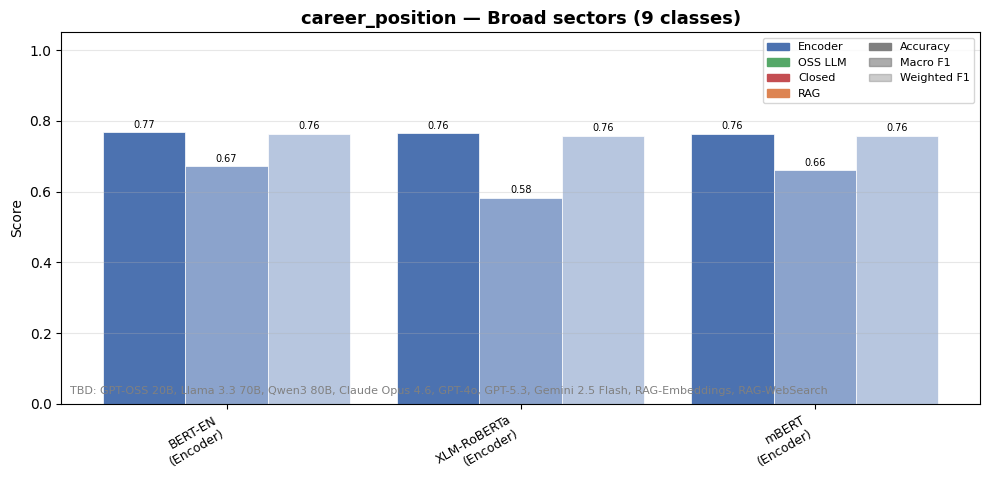

In [6]:
def plot_results(df, title, ax_acc, ax_f1):
    """Plot accuracy and macro F1 grouped by family."""
    has_results = df[df["Accuracy"].notna()].copy()
    tbd_models  = df[df["Accuracy"].isna()]["Model"].tolist()

    metrics = ["Accuracy", "Macro F1", "Weighted F1"]
    x       = np.arange(len(has_results))
    width   = 0.28
    colors_per_metric = ["#2196F3", "#FF9800", "#4CAF50"]

    for ax, metric, color in zip([ax_acc, ax_f1, ax_f1], metrics[:2], colors_per_metric[:2]):
        pass  # we'll use a single grouped chart below

    # --- Grouped bar chart (accuracy + macro_f1 + weighted_f1) ---
    fig_inner, ax = plt.subplots(figsize=(max(10, len(has_results) * 0.9), 5))

    bar_colors = [FAMILY_COLORS[f] for f in has_results["Family"]]

    offsets = [-width, 0, width]
    metric_labels = ["Accuracy", "Macro F1", "Weighted F1"]
    alphas        = [1.0, 0.65, 0.40]

    for offset, metric, alpha in zip(offsets, metric_labels, alphas):
        vals = has_results[metric].values
        bars = ax.bar(
            x + offset, vals, width,
            color=[c + f"{int(255*alpha):02x}" for c in bar_colors],
            label=metric, edgecolor="white", linewidth=0.5,
        )
        for bar, val in zip(bars, vals):
            if pd.notna(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.008,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7,
                )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [f"{row.Model}\n({row.Family})" for _, row in has_results.iterrows()],
        fontsize=9, rotation=30, ha="right",
    )
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=9)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.grid(axis="y", alpha=0.3)

    # Family legend patches
    patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
    ax.legend(
        handles=patches + [
            mpatches.Patch(color="grey",  alpha=1.0, label="Accuracy"),
            mpatches.Patch(color="grey",  alpha=0.65, label="Macro F1"),
            mpatches.Patch(color="grey",  alpha=0.40, label="Weighted F1"),
        ],
        loc="upper right", fontsize=8, ncol=2,
    )

    if tbd_models:
        ax.text(
            0.01, 0.02,
            "TBD: " + ", ".join(tbd_models),
            transform=ax.transAxes, fontsize=8, color="grey",
            va="bottom",
        )

    plt.tight_layout()
    return fig_inner


fig_broad = plot_results(df_broad, "career_position — Broad sectors (9 classes)", None, None)
plt.show()

---
## 4. Fine-grained results (~100 codes)

In [7]:
print("=== FINE-GRAINED (~100 codes) ===")
style_table(df_fine)

Family,Model,Accuracy,Macro F1,Weighted F1
Encoder,BERT-EN,0.4636,0.1674,0.3943
Encoder,XLM-RoBERTa,0.4548,0.1425,0.3698
Encoder,mBERT,0.4678,0.1608,0.3898
OSS LLM,GPT-OSS 20B,TBD,TBD,TBD
OSS LLM,Llama 3.3 70B,TBD,TBD,TBD
OSS LLM,Qwen3 80B,TBD,TBD,TBD
Closed,Claude Opus 4.6,TBD,TBD,TBD
Closed,GPT-4o,TBD,TBD,TBD
Closed,GPT-5.3,TBD,TBD,TBD
Closed,Gemini 2.5 Flash,TBD,TBD,TBD


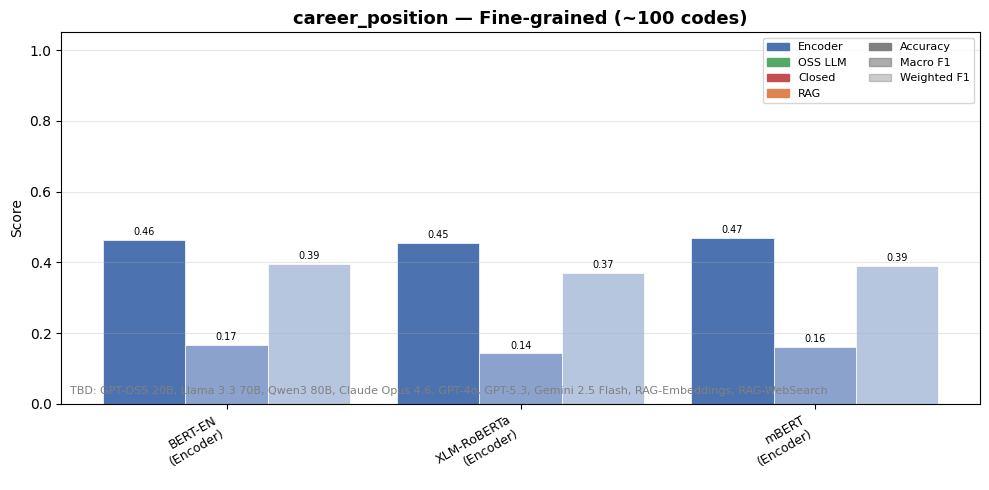

In [8]:
fig_fine = plot_results(df_fine, "career_position — Fine-grained (~100 codes)", None, None)
plt.show()

---
## 5. Side-by-side: Accuracy broad vs fine

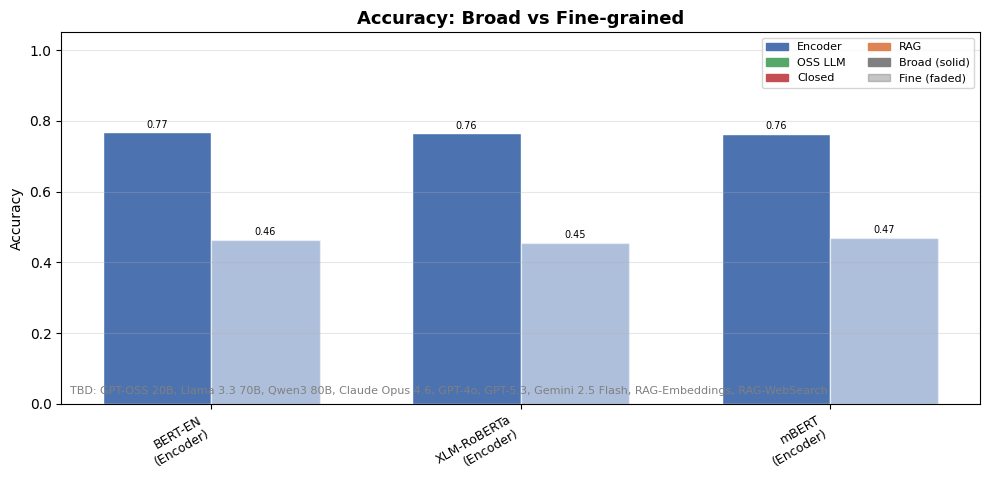

In [9]:
# Models that have BOTH broad and fine results
merged = df_broad[["Family", "Model", "Accuracy", "Macro F1"]].rename(
    columns={"Accuracy": "Acc (broad)", "Macro F1": "MF1 (broad)"}
).merge(
    df_fine[["Model", "Accuracy", "Macro F1"]].rename(
        columns={"Accuracy": "Acc (fine)", "Macro F1": "MF1 (fine)"}
    ),
    on="Model",
)

merged_has = merged[merged["Acc (broad)"].notna() | merged["Acc (fine)"].notna()].copy()

fig, ax = plt.subplots(figsize=(max(10, len(merged_has) * 1.0), 5))

x = np.arange(len(merged_has))
w = 0.35
bar_colors = [FAMILY_COLORS[f] for f in merged_has["Family"]]

b1 = ax.bar(x - w/2, merged_has["Acc (broad)"].fillna(0), w,
            color=bar_colors, label="Accuracy (broad)", alpha=1.0, edgecolor="white")
b2 = ax.bar(x + w/2, merged_has["Acc (fine)"].fillna(0), w,
            color=bar_colors, label="Accuracy (fine)",  alpha=0.45, edgecolor="white")

for bars, col in [(b1, "Acc (broad)"), (b2, "Acc (fine)")]:
    for bar, (_, row) in zip(bars, merged_has.iterrows()):
        val = row[col]
        if pd.notna(val) and val > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r.Model}\n({r.Family})" for _, r in merged_has.iterrows()],
    fontsize=9, rotation=30, ha="right",
)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy: Broad vs Fine-grained", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

family_patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
gran_patches   = [
    mpatches.Patch(color="grey", alpha=1.0,  label="Broad (solid)"),
    mpatches.Patch(color="grey", alpha=0.45, label="Fine (faded)"),
]
ax.legend(handles=family_patches + gran_patches, fontsize=8, ncol=2, loc="upper right")

tbd = merged[merged["Acc (broad)"].isna() & merged["Acc (fine)"].isna()]["Model"].tolist()
if tbd:
    ax.text(0.01, 0.02, "TBD: " + ", ".join(tbd),
            transform=ax.transAxes, fontsize=8, color="grey", va="bottom")

plt.tight_layout()
plt.show()